# LiDAR Curtain Plot — MiniMPL + Prototype Combined

Loads both MiniMPL (`Pict/MiniMPL_*.csv`) and Prototype (`OutputPictCSV/CSVeachday/*.csv`) data for the same date range and produces curtain (time × range) colour plots for both.

In [2]:
import re
import os
from pathlib import Path
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Date range ────────────────────────────────────────────────────────────────
START_DATE_STR = "02-02-2026"
END_DATE_STR   = "06-02-2026"
DATE_FORMAT    = "%d-%m-%Y"

start_date = pd.to_datetime(START_DATE_STR, format=DATE_FORMAT).normalize()
end_date   = pd.to_datetime(END_DATE_STR,   format=DATE_FORMAT).normalize()

# ── Data paths ────────────────────────────────────────────────────────────────
MINIMPL_DIR  = Path("/Users/thunthita/LidarNRBPipeline/LIDar/src/Pict/")
PROTO_DIR    = Path("/Users/thunthita/LidarNRBPipeline/LIDar/src/OutputPictCSV/CSVeachday/")
SAVE_DIR     = "CombinedFigures"
PBOX_DIR     = Path("/Users/thunthita/LidarNRBPipeline/LIDar/src/OutputPictCSV/CSVeachday/PBOX/")

date_pat = re.compile(r"(\d{2}-\d{2}-\d{4})")

def extract_date(fname: str):
    m = date_pat.search(fname)
    return pd.to_datetime(m.group(1), format=DATE_FORMAT).normalize() if m else None


# ── PBL toggle (set False to hide PBL overlay) ───────────────────────────────
SHOW_PBL = True

# ── Y-axis tick config ───────────────────────────────────────────────────────
YTICK_MAX  = 15000   # highest tick (m)
YTICK_STEP = 3000    # spacing between ticks (m)


## Part 1 — Load MiniMPL data

In [4]:
files_mpl = sorted(
    [(f, extract_date(f.name)) for f in MINIMPL_DIR.glob("MiniMPL_*.csv")
     if extract_date(f.name) is not None
     and start_date <= extract_date(f.name) <= end_date],
    key=lambda x: x[1]
)

print("MiniMPL files:")
for f, d in files_mpl:
    print(" ", f.name, "->", d.date())

dfs_mpl = []
for f, d in files_mpl:
    tmp = pd.read_csv(f)
    tmp["date"] = d
    dfs_mpl.append(tmp)

df_mpl = pd.concat(dfs_mpl, ignore_index=True)
print("\nMiniMPL shape:", df_mpl.shape)
print("Columns:", list(df_mpl.columns))


MiniMPL files:
  MiniMPL_02-02-2026.csv -> 2026-02-02
  MiniMPL_03-02-2026.csv -> 2026-02-03
  MiniMPL_04-02-2026.csv -> 2026-02-04
  MiniMPL_05-02-2026.csv -> 2026-02-05
  MiniMPL_06-02-2026.csv -> 2026-02-06

MiniMPL shape: (1439000, 17)
Columns: ['day', 'timestamp', 'range_raw', 'range_m_for_NRB', 'range_m', 'copol_raw', 'copol_snr', 'copol_background', 'copol_nrb', 'crosspol_raw', 'crosspol_snr', 'crosspol_background', 'crosspol_nrb', 'laser_energy', 'pbls', 'Normalize_copol_nrb', 'date']


In [5]:
# ── Ensure numeric types ──────────────────────────────────────────────────────
for col in ["range_m_for_NRB", "copol_raw", "copol_background",
            "crosspol_raw", "crosspol_background",
            "copol_nrb", "crosspol_nrb"]:
    if col in df_mpl.columns:
        df_mpl[col] = pd.to_numeric(df_mpl[col], errors="coerce")

df_mpl["timestamp"] = pd.to_datetime(df_mpl["timestamp"], errors="coerce")

# ── Range² signals ────────────────────────────────────────────────────────────
bg_co    = df_mpl["copol_background"].iloc[0]
bg_cross = df_mpl["crosspol_background"].iloc[0]

df_mpl["range_square_co"]    = (df_mpl["copol_raw"]    - bg_co)    * df_mpl["range_m_for_NRB"]**2
df_mpl["range_square_cross"] = (df_mpl["crosspol_raw"] - bg_cross) * df_mpl["range_m_for_NRB"]**2

df_mpl["range_square_co_norm"]    = df_mpl["range_square_co"]    / df_mpl["range_square_co"].max()
df_mpl["range_square_cross_norm"] = df_mpl["range_square_cross"] / df_mpl["range_square_cross"].max()

print("MiniMPL processing done.")


MiniMPL processing done.


In [6]:
# ── Filter to date range ──────────────────────────────────────────────────────
start_ts = start_date
end_ts   = end_date + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)

df_mpl_sel = df_mpl.loc[
    df_mpl["timestamp"].between(start_ts, end_ts, inclusive="both")
].copy()

df_mpl_sel = df_mpl_sel.dropna(
    subset=["timestamp", "range_m_for_NRB",
            "range_square_co", "range_square_cross",
            "copol_nrb", "crosspol_nrb"]
)

def pivot_Z(df, range_col, val_col):
    return df.pivot_table(
        index=range_col,
        columns="timestamp",
        values=val_col,
        aggfunc="mean"
    ).sort_index()

Z_mpl_co_pr2    = pivot_Z(df_mpl_sel, "range_m_for_NRB", "range_square_co")
Z_mpl_cross_pr2 = pivot_Z(df_mpl_sel, "range_m_for_NRB", "range_square_cross")
Z_mpl_co_nrb    = pivot_Z(df_mpl_sel, "range_m_for_NRB", "copol_nrb")
Z_mpl_cross_nrb = pivot_Z(df_mpl_sel, "range_m_for_NRB", "crosspol_nrb")

# ── Depolarisation ratio ──────────────────────────────────────────────────────
ratio          = Z_mpl_co_pr2 / Z_mpl_cross_pr2.replace(0, np.nan)
Z_mpl_depol    = ratio / (ratio + 1)

# ── PBL series ────────────────────────────────────────────────────────────────
pbl_series = (
    df_mpl_sel.sort_values(["timestamp", "range_m_for_NRB"])
              .groupby("timestamp")["pbls"]
              .first()
)

print("Z MiniMPL copol NRB shape:", Z_mpl_co_nrb.shape)
print("PBL series length:", pbl_series.notna().sum(), "valid points")


Z MiniMPL copol NRB shape: (664, 1439)
PBL series length: 1439 valid points


## Part 2 — Load Prototype data

In [8]:
files_pro = sorted(
    [(f, extract_date(f.name)) for f in PROTO_DIR.glob("*.csv")
     if extract_date(f.name) is not None
     and start_date <= extract_date(f.name) <= end_date
     and not f.name.startswith("pbls_")],   # exclude pbls files
    key=lambda x: x[1]
)

print("Prototype files:")
for f, d in files_pro:
    print(" ", f.name, "->", d.date())

dfs_pro = []
for f, d in files_pro:
    tmp = pd.read_csv(f)
    tmp["date"] = d
    dfs_pro.append(tmp)

df_pro = pd.concat(dfs_pro, ignore_index=True)
df_pro.insert(0, "date", df_pro.pop("date"))
df_pro.insert(1, "range_m", df_pro.pop("range_m"))

print("\nPrototype shape:", df_pro.shape)


Prototype files:
  02-02-2026.csv -> 2026-02-02
  03-02-2026.csv -> 2026-02-03
  04-02-2026.csv -> 2026-02-04
  05-02-2026.csv -> 2026-02-05
  06-02-2026.csv -> 2026-02-06

Prototype shape: (20000, 50)


In [9]:
df_pro["date"] = pd.to_datetime(df_pro["date"], errors="coerce")
df_pro_sel = df_pro.loc[
    df_pro["date"].between(start_date, end_date, inclusive="both")
].copy()

# ── Wide → long ───────────────────────────────────────────────────────────────
time_cols = [c for c in df_pro_sel.columns
             if re.fullmatch(r"\d{1,2}\.\d{2}", str(c))]

df_long = df_pro_sel.melt(
    id_vars=["date", "range_m"],
    value_vars=time_cols,
    var_name="time",
    value_name="signal"
)

df_long["datetime"] = pd.to_datetime(
    df_long["date"].dt.strftime("%Y-%m-%d") + " " +
    df_long["time"].astype(str).str.replace(".", ":", regex=False),
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

df_long = df_long.dropna(subset=["range_m", "signal", "datetime"])

Z_proto = df_long.pivot_table(
    index="range_m",
    columns="datetime",
    values="signal",
    aggfunc="mean"
).sort_index()

print("Z Prototype shape:", Z_proto.shape,
      f"({Z_proto.shape[0]} range bins × {Z_proto.shape[1]} timestamps)")


Z Prototype shape: (4000, 240) (4000 range bins × 240 timestamps)


## Part 3 — Load PBOX NRB data

In [11]:
# ── PBOX NRB files: NRB-YYYY-MM-DD.csv ───────────────────────────────────────
pbox_date_pat = re.compile(r"NRB-(\d{4}-\d{2}-\d{2})")

def extract_pbox_date(fname):
    m = pbox_date_pat.search(fname)
    return pd.to_datetime(m.group(1)).normalize() if m else None

files_pbox = sorted(
    [(f, extract_pbox_date(f.name)) for f in PBOX_DIR.glob("NRB-*.csv")
     if extract_pbox_date(f.name) is not None
     and start_date <= extract_pbox_date(f.name) <= end_date],
    key=lambda x: x[1]
)

print("PBOX files:")
for f, d in files_pbox:
    print(" ", f.name, "->", d.date())

dfs_pbox = []
for f, d in files_pbox:
    tmp = pd.read_csv(f, index_col=0)            # Range(m) as index
    tmp.columns = pd.to_datetime(tmp.columns)    # columns already full datetime
    dfs_pbox.append(tmp)

# Concat along columns (time axis) → Z_pbox: range_m × datetime
Z_pbox = pd.concat(dfs_pbox, axis=1).sort_index()
Z_pbox.index.name = "range_m"

print(f"Z_pbox shape: {Z_pbox.shape}  ({Z_pbox.shape[0]} range bins × {Z_pbox.shape[1]} timestamps)")
print(f"Range: {Z_pbox.index.min():.2f} – {Z_pbox.index.max():.2f} m")
print(f"Time:  {Z_pbox.columns[0]} – {Z_pbox.columns[-1]}")


PBOX files:
  NRB-2026-02-02.csv -> 2026-02-02
  NRB-2026-02-03.csv -> 2026-02-03
  NRB-2026-02-04.csv -> 2026-02-04
  NRB-2026-02-05.csv -> 2026-02-05
  NRB-2026-02-06.csv -> 2026-02-06
Z_pbox shape: (4000, 240)  (4000 range bins × 240 timestamps)
Range: 3.75 – 15000.00 m
Time:  2026-02-02 00:05:00 – 2026-02-06 23:35:00


## Part 4 — plot_lidar_curtain function

In [13]:
def plot_lidar_curtain(
    Z,
    start_date,
    end_date,
    title="",
    scale="linear",
    save=True,
    save_dir=SAVE_DIR,
    ylim=None,
    xlim=None,
    clim=None,
    cmap="jet",
    invert_y=False,
    pbls=None,
    pbl_style="line",
    pbl_color="white",
    pbl_label="PBL",
    pbl_align="nearest",
    pbl_tol="5min",
    ytick_max=15000,
    ytick_step=3000,
):
    """
    Z          : 2D DataFrame — index = range (m), columns = datetime
    title      : extra string appended to plot title
    scale      : 'linear' or 'log'
    ylim/xlim  : axis limits
    clim       : colour limits (vmin, vmax)
    cmap       : colormap
    pbls       : pd.Series (index=datetime, values=PBL height in metres)
    pbl_align  : 'exact' or 'nearest'
    """
    if scale == "log":
        Z_plot      = np.log10(Z.clip(lower=1e-6))
        color_label = "log\u2081\u2080(Signal)"
        scale_tag   = "log10"
    else:
        Z_plot      = Z.copy()
        color_label = "Signal"
        scale_tag   = "linear"

    fig, ax = plt.subplots(figsize=(14, 6))

    pcm = ax.pcolormesh(
        Z_plot.columns, Z_plot.index, Z_plot.values,
        shading="auto", cmap=cmap
    )

    if clim is not None:
        pcm.set_clim(*clim)

    # ── PBL overlay ───────────────────────────────────────────────────────────
    if pbls is not None:
        pbls = pbls.copy()
        pbls.index = pd.to_datetime(pbls.index, errors="coerce")
        pbls = pbls.dropna()

        Z_cols = pd.to_datetime(Z.columns, errors="coerce")

        if pbl_align == "nearest":
            pbl_line = pbls.reindex(Z_cols, method="nearest",
                                    tolerance=pd.Timedelta(pbl_tol))
        else:
            pbl_line = pbls.reindex(Z_cols)

        pbl_line.index = Z_cols
        pbl_line = pd.to_numeric(pbl_line, errors="coerce")
        pbl_line = pbl_line.where(np.isfinite(pbl_line)).dropna()

        if len(pbl_line) > 0:
            if pbl_style == "scatter":
                ax.scatter(pbl_line.index, pbl_line.values,
                           s=10, color=pbl_color, label=pbl_label, zorder=10)
            else:
                ax.plot(pbl_line.index, pbl_line.values,
                        linewidth=1.5, color=pbl_color,
                        label=pbl_label, zorder=10)
            ax.legend(loc="upper right", fontsize=9)
        else:
            print("\u26a0\ufe0f  PBL: no valid points after alignment")

    # ── Axes formatting ───────────────────────────────────────────────────────
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y\n%H:%M"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    ax.set_xlabel("Time")
    ax.set_ylabel("Range (m)")

    if ylim is not None:
        ax.set_ylim(ylim)
    if xlim is not None:
        ax.set_xlim(xlim)
    if invert_y:
        ax.invert_yaxis()

    ax.set_yticks(range(0, ytick_max + 1, ytick_step))

    ax.set_title(
        f"{title} ({scale_tag})  "
        f"{pd.to_datetime(start_date):%d %b %Y} \u2013 "
        f"{pd.to_datetime(end_date):%d %b %Y}"
    )

    fig.colorbar(pcm, ax=ax, label=color_label)
    plt.tight_layout()

    if save:
        os.makedirs(save_dir, exist_ok=True)
        fname = (
            f"{title.replace(' ', '_')}_{scale_tag}_"
            f"{pd.to_datetime(start_date):%Y%m%d}_{pd.to_datetime(end_date):%Y%m%d}.png"
        )
        save_path = os.path.join(save_dir, fname)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved \u2192 {save_path}")

    plt.show()


## Part 5 — MiniMPL curtain plots

Saved → CombinedFigures/MiniMPL_Copol_NRB_linear_20260202_20260206.png


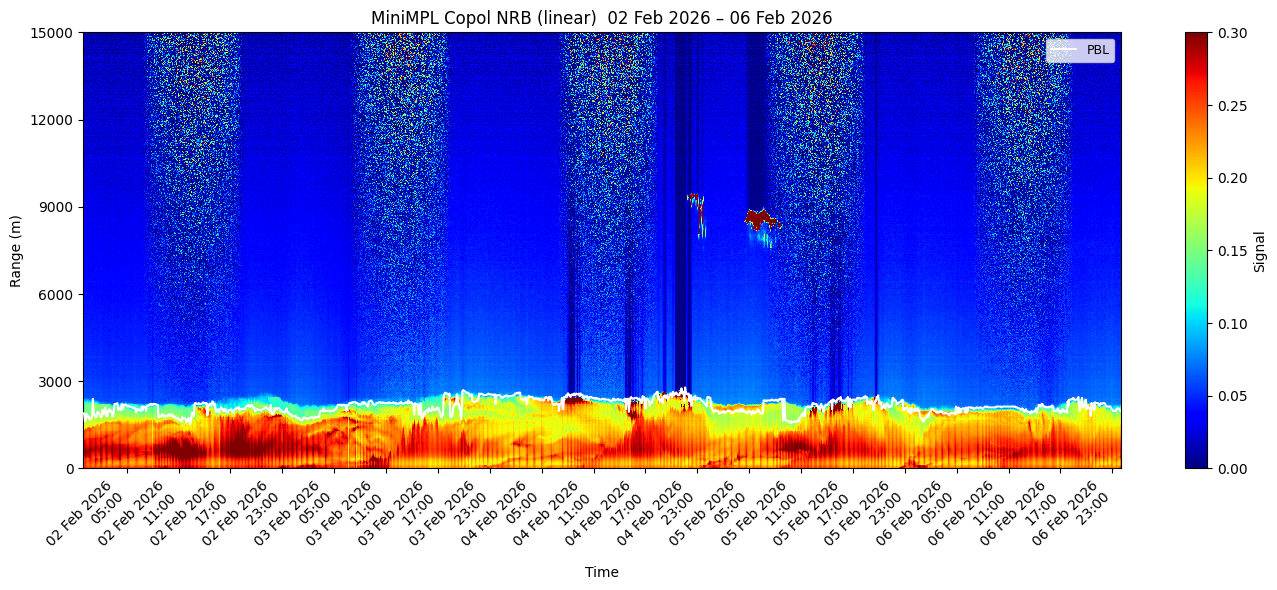

In [15]:
plot_lidar_curtain(
    Z_mpl_co_nrb,
    start_date, end_date,
    title="MiniMPL Copol NRB",
    scale="linear",
    ylim=(0, 11000),
    clim=(0, 0.3),
    cmap="jet",
    pbls=pbl_series * 1000 if SHOW_PBL else None,   # km -> m
    pbl_color="white",
)


Saved → CombinedFigures/MiniMPL_Crosspol_NRB_log10_20260202_20260206.png


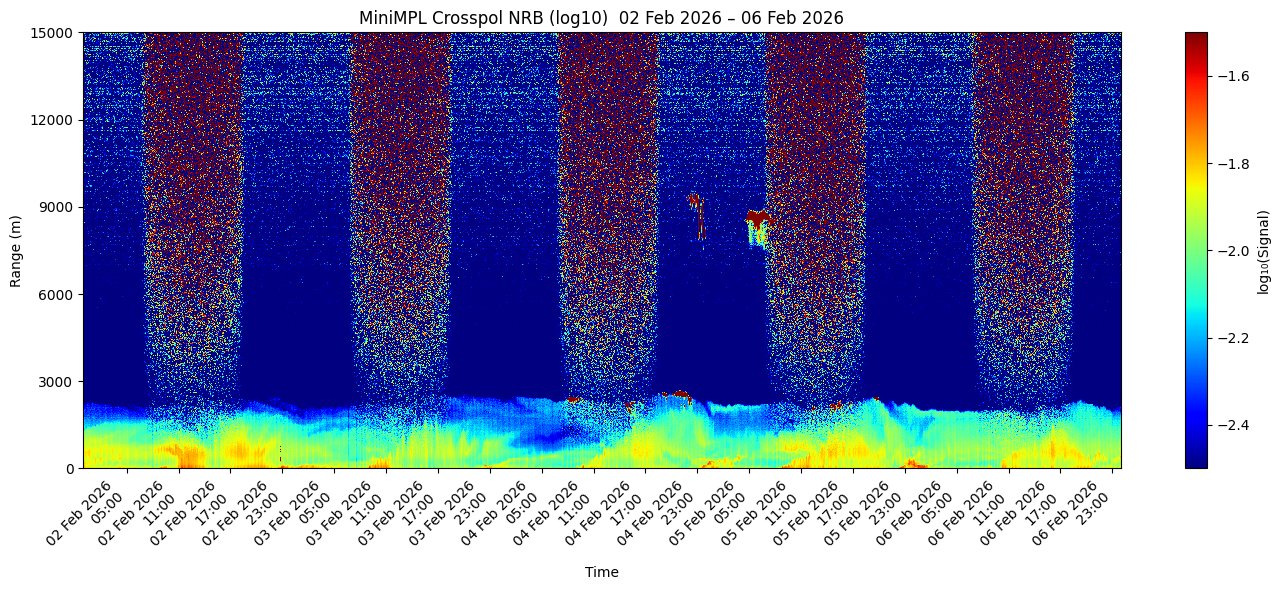

In [16]:
plot_lidar_curtain(
    Z_mpl_cross_nrb,
    start_date, end_date,
    title="MiniMPL Crosspol NRB",
    scale="log",
    ylim=(0, 11000),
    clim=(-2.5, -1.5),
    cmap="jet",
)


Saved → CombinedFigures/MiniMPL_Depolarisation_Ratio_linear_20260202_20260206.png


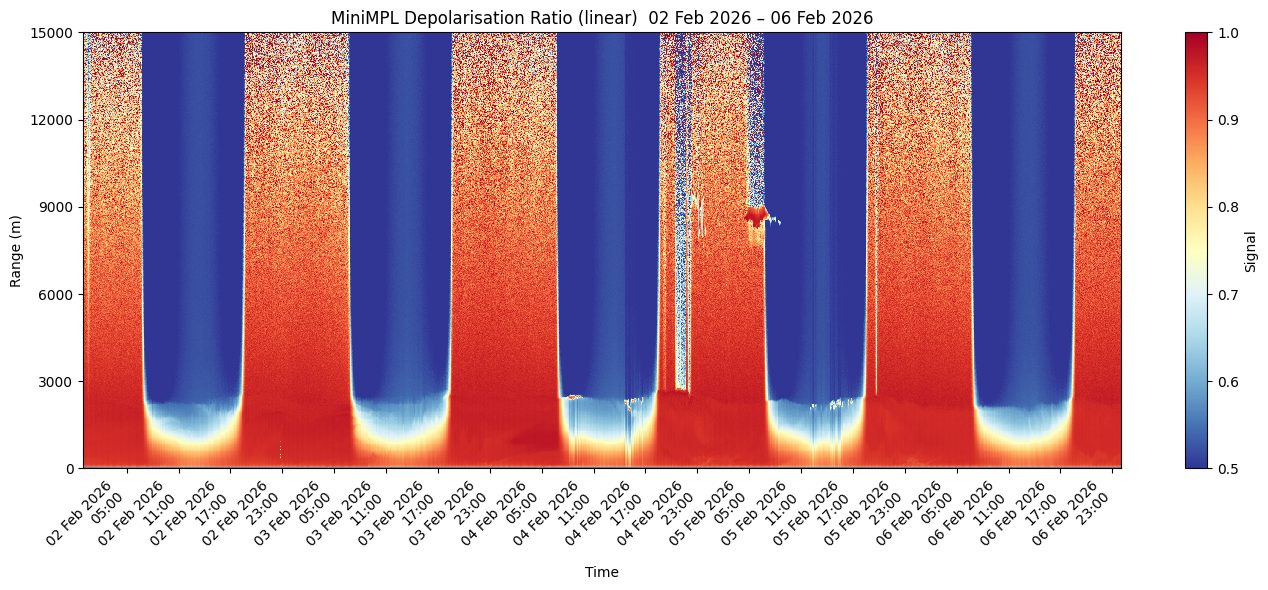

In [17]:
plot_lidar_curtain(
    Z_mpl_depol,
    start_date, end_date,
    title="MiniMPL Depolarisation Ratio",
    scale="linear",
    ylim=(0, 5000),
    clim=(0.5, 1),
    cmap="RdYlBu_r",
)


## Part 6 — Prototype curtain plot

Saved → CombinedFigures/Prototype_NRB_(range²_normalized)_linear_20260202_20260206.png


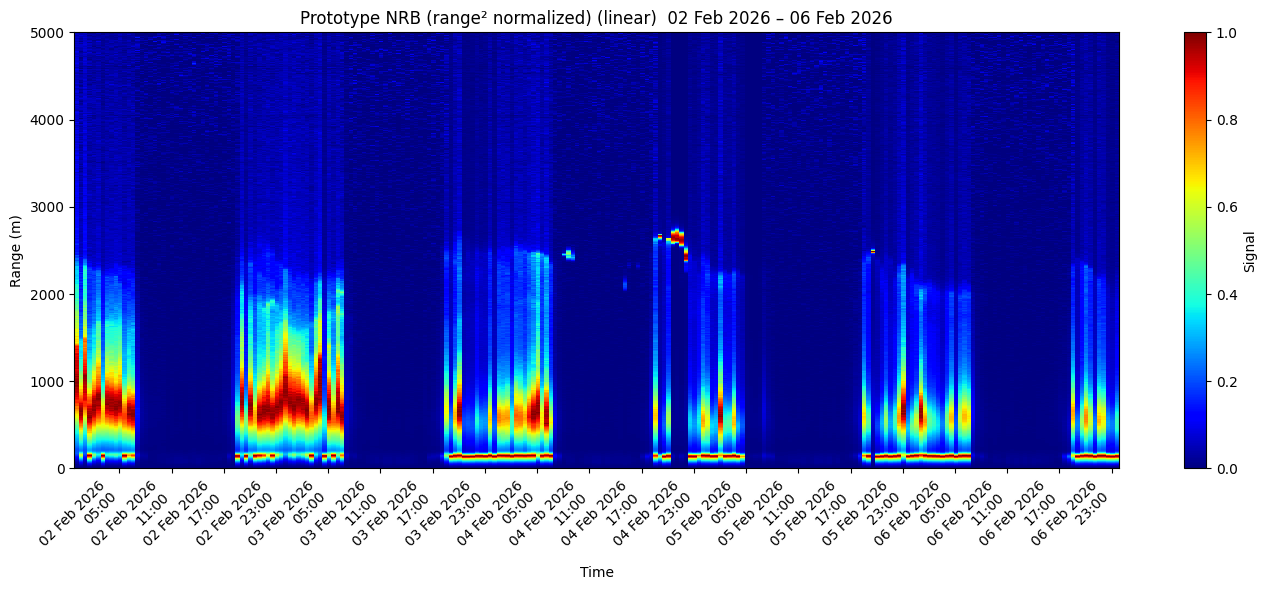

In [19]:
plot_lidar_curtain(
    Z_proto,
    start_date, end_date,
    title="Prototype NRB (range² normalized)",
    scale="linear",
    ylim=(0, 5000),
    clim=(0, 1),
    cmap="jet",
    ytick_max=5000,
    ytick_step=1000,
)


## Part 7 — PBOX NRB curtain plot

Saved → CombinedFigures/PBOX_NRB_linear_20260202_20260206.png


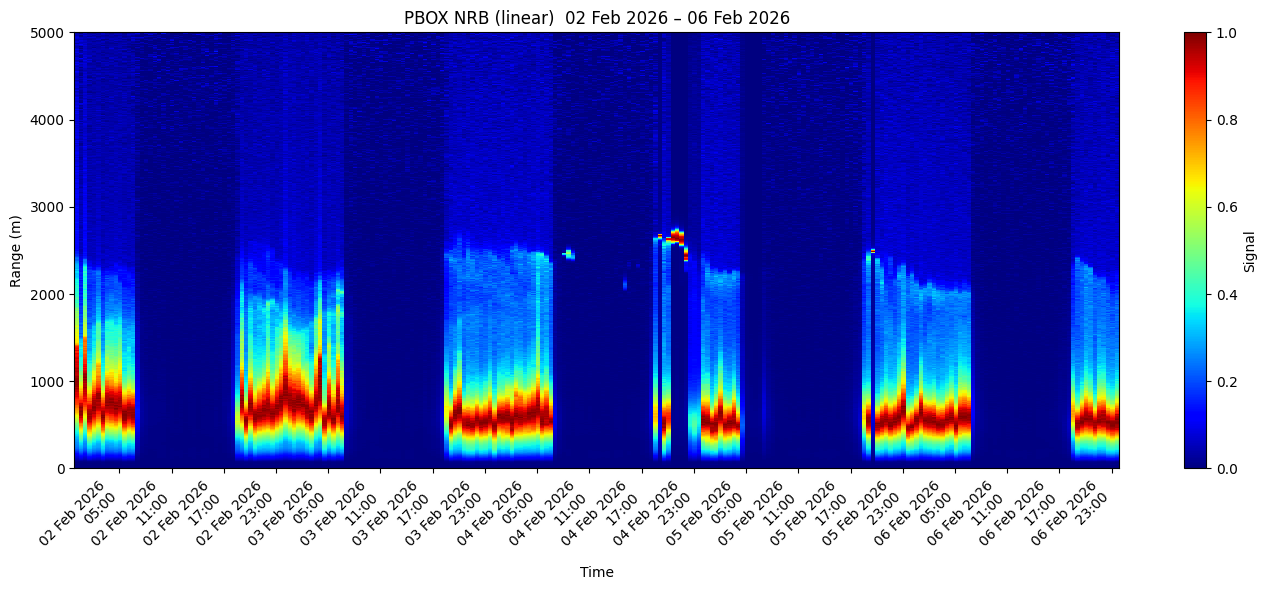

In [21]:
plot_lidar_curtain(
    Z_pbox,
    start_date, end_date,
    title="PBOX NRB",
    scale="linear",
    ylim=(0, 5000),
    clim=(0, 1),
    cmap="jet",
    ytick_max=5000,
    ytick_step=1000,
)


## Part 7b — Photon-only and Analog-only curtain plots

Builds curtain matrices directly from per-timestamp processed CSVs:
- **Photon-only**: `photon_deadtime` − far-range bg → × range² → normalized
- **Analog-only**: `analog_scaled_for_glue` − far-range bg → × range² → normalized

In [23]:
def build_curtain_from_proc_csvs(start_date, end_date, vcol, bg_start_m=10000, bg_end_m=15000,
                                  proto_base=None):
    """
    Build a wide curtain DataFrame (range_m × datetime) from per-timestamp processed CSVs.

    For each timestamp CSV:
      1. Load vcol (e.g. 'photon_deadtime' or 'analog')
      2. Subtract far-range background mean (bg_start_m – bg_end_m)
      3. Multiply by range_m²
      4. Normalize per-timestamp to [0, 1]
    """
    if proto_base is None:
        proto_base = Path("/Users/thunthita/LidarNRBPipeline/LIDar/src/OutputPictCSV")

    cols_data = {}   # datetime → pd.Series(range_m)

    for day_dt in pd.date_range(start_date, end_date, freq="D"):
        day_str  = day_dt.strftime("%d-%m-%Y")
        date_fmt = day_dt.strftime("%Y-%m-%d")

        for hh in range(24):
            for mm in (5, 35):
                ts   = pd.Timestamp(f"{date_fmt} {hh:02d}:{mm:02d}")
                hhmm = f"{hh:02d}{mm:02d}"

                csv_path = proto_base / f"{day_str}-{hhmm}" / f"{day_str}-{hhmm}_processed.csv"
                if not csv_path.exists():
                    continue

                df = pd.read_csv(csv_path)
                df["range_m"] = pd.to_numeric(df["range_m"], errors="coerce")
                df = df.dropna(subset=["range_m"]).sort_values("range_m").reset_index(drop=True)

                if vcol not in df.columns:
                    continue

                sig     = pd.to_numeric(df[vcol], errors="coerce")
                bg_mask = (df["range_m"] >= bg_start_m) & (df["range_m"] <= bg_end_m)
                bg      = sig[bg_mask].mean() if bg_mask.any() else 0.0
                r2      = (sig - bg) * df["range_m"] ** 2

                mx = r2.max()
                if np.isfinite(mx) and mx > 0:
                    r2_norm = r2 / mx
                else:
                    r2_norm = pd.Series(np.nan, index=r2.index)

                cols_data[ts] = pd.Series(r2_norm.values, index=df["range_m"].values)

    if not cols_data:
        print(f"[WARN] No data found for column '{vcol}'")
        return pd.DataFrame()

    Z = pd.DataFrame(cols_data).sort_index(axis=1).sort_index(axis=0)
    Z.index.name = "range_m"
    return Z


print("Building Z_photon_only ...")
Z_photon_only = build_curtain_from_proc_csvs(start_date, end_date, vcol="photon_deadtime")
print(f"  shape: {Z_photon_only.shape}")

print("Building Z_analog_only ...")
Z_analog_only = build_curtain_from_proc_csvs(start_date, end_date, vcol="analog")
print(f"  shape: {Z_analog_only.shape}")

Building Z_photon_only ...
  shape: (4000, 240)
Building Z_analog_only ...
  shape: (4000, 240)


Saved → CombinedFigures/Prototype_—_Photon-only_NRB_(range²_normalized)_linear_20260202_20260206.png


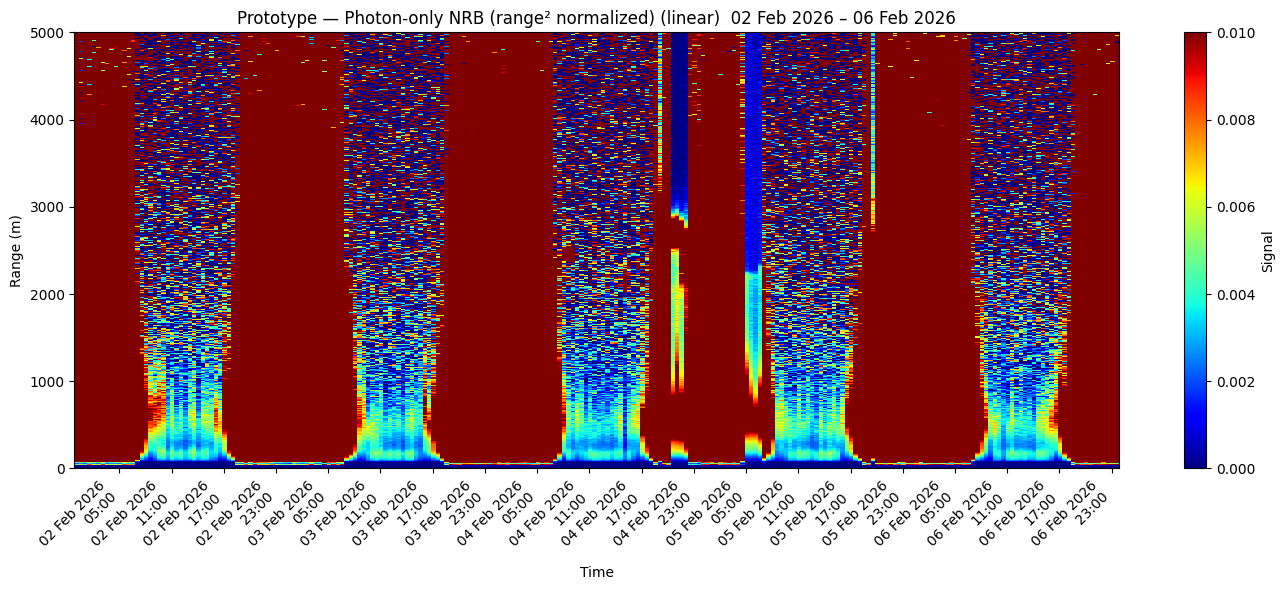

In [24]:
plot_lidar_curtain(
    Z_photon_only,
    start_date, end_date,
    title="Prototype — Photon-only NRB (range² normalized)",
    scale="linear",
    ylim=(0, 5000),
    clim=(0, 0.01),
    cmap="jet",
    ytick_max=5000,
    ytick_step=1000,
)

Saved → CombinedFigures/Prototype_—_Analog-only_NRB_(range²_normalized)_linear_20260202_20260206.png


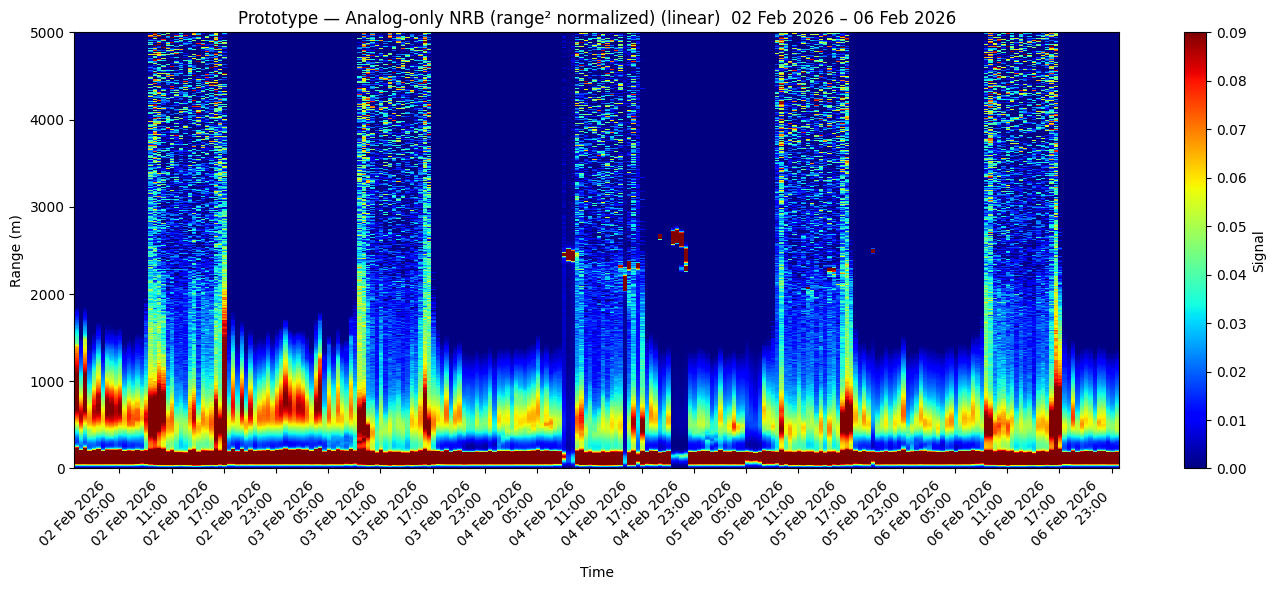

In [25]:
plot_lidar_curtain(
    Z_analog_only,
    start_date, end_date,
    title="Prototype — Analog-only NRB (range² normalized)",
    scale="linear",
    ylim=(0, 5000),
    clim=(0, 0.09),
    cmap="jet",
    ytick_max=5000,
    ytick_step=1000,
)

## Part 9 — Glued vs Photon-only vs Analog-only: RMSE against MiniMPL

Compares three prototype NRB variants against MiniMPL (reference) over range **1000–10000 m** (above afterpulse + overlap uncertainty zone).

In [27]:
def compute_rmse_profile(prof_ref, prof_test, range_min=1000, range_max=10000):
    """
    RMSE between two range profiles over [range_min, range_max].
    Both profiles are pd.Series with range (m) as index.
    Each is normalized to [0,1] independently before comparison.
    """
    r_common = np.arange(range_min, range_max + 1, 30.0)

    ref_interp  = np.interp(r_common, prof_ref.index.astype(float),
                            prof_ref.values.astype(float),  left=np.nan, right=np.nan)
    test_interp = np.interp(r_common, prof_test.index.astype(float),
                            prof_test.values.astype(float), left=np.nan, right=np.nan)

    def norm01(x):
        finite = x[np.isfinite(x)]
        if len(finite) < 5 or finite.max() == finite.min():
            return np.full_like(x, np.nan)
        return (x - finite.min()) / (finite.max() - finite.min())

    ref_n  = norm01(ref_interp)
    test_n = norm01(test_interp)

    mask = np.isfinite(ref_n) & np.isfinite(test_n)
    if mask.sum() < 5:
        return np.nan
    return float(np.sqrt(np.mean((ref_n[mask] - test_n[mask])**2)))


In [28]:
from pathlib import Path

PROTO_BASE_PROC = Path("/Users/thunthita/LidarNRBPipeline/LIDar/src/OutputPictCSV")
RMSE_RANGE      = (1000, 10000)
BG_START_M      = 10000
BG_END_M        = 15000

rmse_results = []

for day_dt in pd.date_range(start_date, end_date, freq="D"):
    day_str  = day_dt.strftime("%d-%m-%Y")
    date_fmt = day_dt.strftime("%Y-%m-%d")

    times_30min = pd.date_range(
        start=f"{date_fmt} 00:05",
        end=f"{date_fmt} 23:55",
        freq="30min"
    )

    for ts in times_30min:
        ts   = pd.Timestamp(ts).floor("min")
        hhmm = ts.strftime("%H%M")

        proto_csv = PROTO_BASE_PROC / f"{day_str}-{hhmm}" / f"{day_str}-{hhmm}_processed.csv"
        if not proto_csv.exists():
            continue

        df_p = pd.read_csv(proto_csv)
        df_p["range_m"] = pd.to_numeric(df_p["range_m"], errors="coerce")
        df_p = df_p.dropna(subset=["range_m"]).sort_values("range_m").reset_index(drop=True)

        r = df_p["range_m"].values
        bg_mask = (df_p["range_m"] >= BG_START_M) & (df_p["range_m"] <= BG_END_M)

        # ── Glued ─────────────────────────────────────────────────────────────
        glued_vals = pd.to_numeric(df_p["range2_norm"], errors="coerce").values
        prof_glued = pd.Series(glued_vals, index=r).dropna()

        # ── Photon-only: photon_deadtime − bg → × r² → normalize ─────────────
        phot    = pd.to_numeric(df_p["photon_deadtime"], errors="coerce")
        phot_bg = phot[bg_mask].mean() if bg_mask.any() else 0.0
        phot_r2 = (phot - phot_bg) * df_p["range_m"] ** 2
        pmax    = phot_r2.max()
        prof_photon = pd.Series(
            (phot_r2 / pmax).values if (np.isfinite(pmax) and pmax > 0) else np.full(len(r), np.nan),
            index=r
        ).dropna()

        # ── Analog-only (raw): analog − bg → × r² → normalize ────────────────
        ana    = pd.to_numeric(df_p["analog"], errors="coerce")
        ana_bg = ana[bg_mask].mean() if bg_mask.any() else 0.0
        ana_r2 = (ana - ana_bg) * df_p["range_m"] ** 2
        amax   = ana_r2.max()
        prof_analog = pd.Series(
            (ana_r2 / amax).values if (np.isfinite(amax) and amax > 0) else np.full(len(r), np.nan),
            index=r
        ).dropna()

        # ── MiniMPL reference ─────────────────────────────────────────────────
        cols_mpl = pd.to_datetime(Z_mpl_co_nrb.columns, errors="coerce")
        diffs    = pd.Series(cols_mpl - ts).abs()
        idx      = diffs.argmin()
        if diffs.iloc[idx] > pd.Timedelta("30min"):
            continue

        mpl_col  = Z_mpl_co_nrb.iloc[:, idx]
        prof_mpl = pd.Series(
            mpl_col.values.astype(float),
            index=mpl_col.index.astype(float)
        ).dropna()

        mpl_max = prof_mpl.max()
        if not (np.isfinite(mpl_max) and mpl_max > 0):
            continue
        prof_mpl_norm = prof_mpl / mpl_max

        rmse_results.append({
            "timestamp":    ts,
            "rmse_glued":   compute_rmse_profile(prof_mpl_norm, prof_glued,  *RMSE_RANGE),
            "rmse_photon":  compute_rmse_profile(prof_mpl_norm, prof_photon, *RMSE_RANGE),
            "rmse_analog":  compute_rmse_profile(prof_mpl_norm, prof_analog, *RMSE_RANGE),
        })

df_rmse = pd.DataFrame(rmse_results)
print(f"Computed RMSE for {len(df_rmse)} timestamps")
print(df_rmse[["rmse_glued", "rmse_photon", "rmse_analog"]].describe().round(4))

Computed RMSE for 240 timestamps
       rmse_glued  rmse_photon  rmse_analog
count    240.0000     240.0000     240.0000
mean       0.2008       0.2008       0.2714
std        0.1140       0.1140       0.0676
min        0.0336       0.0335       0.1013
25%        0.0993       0.0995       0.2449
50%        0.1892       0.1891       0.2699
75%        0.2932       0.2932       0.2910
max        0.5628       0.5629       0.5902


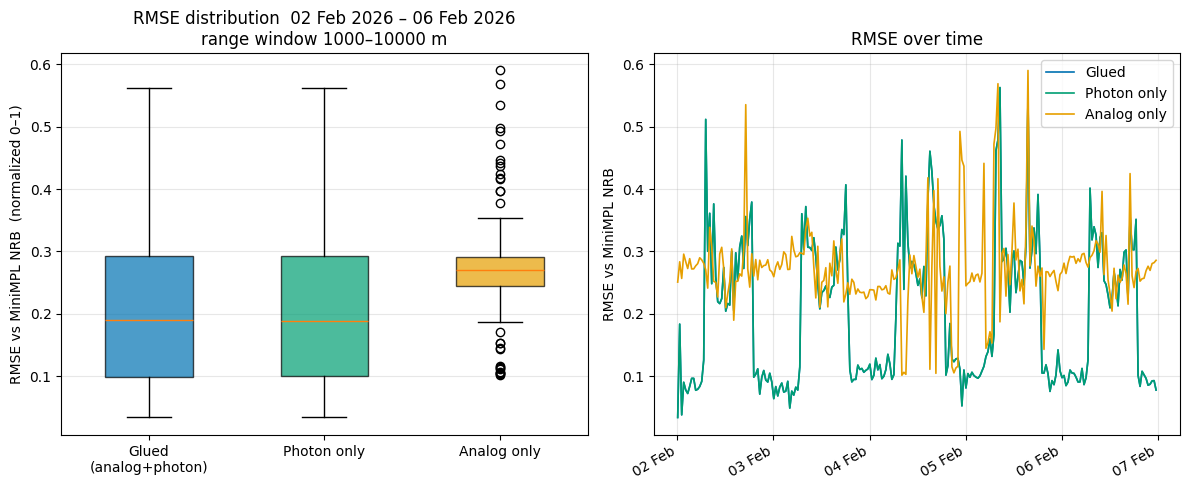


Mean RMSE:
  Glued          : 0.2008
  Photon only    : 0.2008
  Analog only    : 0.2714

✅ Best method (lowest mean RMSE): Glued


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Boxplot ───────────────────────────────────────────────────────────────────
ax = axes[0]
data  = [df_rmse["rmse_glued"].dropna(),
         df_rmse["rmse_photon"].dropna(),
         df_rmse["rmse_analog"].dropna()]
labels = ["Glued\n(analog+photon)", "Photon only", "Analog only"]
colors = ["#0072B2", "#009E73", "#E69F00"]

bp = ax.boxplot(data, patch_artist=True, notch=False, widths=0.5)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels(labels)
ax.set_ylabel("RMSE vs MiniMPL NRB  (normalized 0–1)")
ax.set_title(f"RMSE distribution  {start_date:%d %b %Y} – {end_date:%d %b %Y}\n"
             f"range window {RMSE_RANGE[0]}–{RMSE_RANGE[1]} m")
ax.grid(True, alpha=0.3, axis="y")

# ── Time series ───────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(df_rmse["timestamp"], df_rmse["rmse_glued"],  label="Glued",       color="#0072B2", linewidth=1.2)
ax2.plot(df_rmse["timestamp"], df_rmse["rmse_photon"], label="Photon only", color="#009E73", linewidth=1.2)
ax2.plot(df_rmse["timestamp"], df_rmse["rmse_analog"], label="Analog only", color="#E69F00", linewidth=1.2)

ax2.xaxis.set_major_locator(mdates.DayLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax2.set_ylabel("RMSE vs MiniMPL NRB")
ax2.set_title("RMSE over time")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.setp(ax2.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
os.makedirs(SAVE_DIR, exist_ok=True)
fig.savefig(f"{SAVE_DIR}/rmse_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print("\nMean RMSE:")
for col, lbl in [("rmse_glued","Glued"), ("rmse_photon","Photon only"), ("rmse_analog","Analog only")]:
    print(f"  {lbl:15s}: {df_rmse[col].mean():.4f}")

best = df_rmse[["rmse_glued","rmse_photon","rmse_analog"]].mean().idxmin()
name = {"rmse_glued":"Glued","rmse_photon":"Photon only","rmse_analog":"Analog only"}[best]
print(f"\n\u2705 Best method (lowest mean RMSE): {name}")


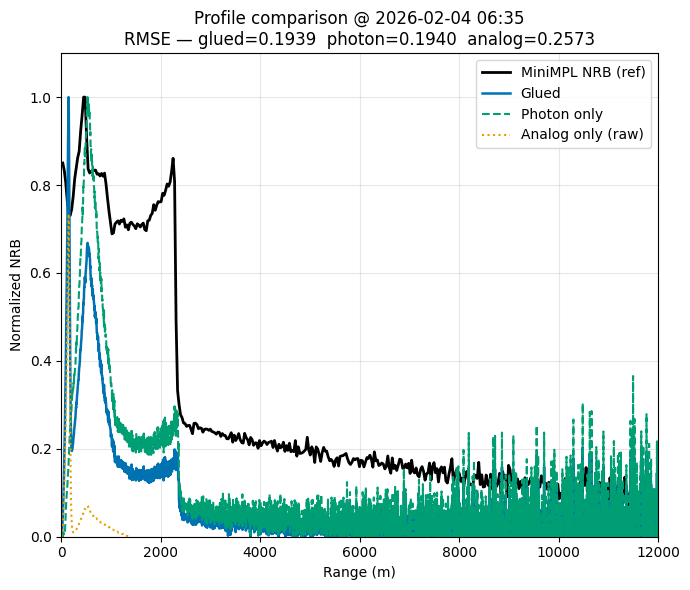

In [30]:
# ── Pick the timestamp with median RMSE of glued to see a typical case ────────
median_idx = (df_rmse["rmse_glued"] - df_rmse["rmse_glued"].median()).abs().idxmin()
ts_ex      = df_rmse.loc[median_idx, "timestamp"]
day_str_ex = ts_ex.strftime("%d-%m-%Y")
hhmm_ex    = ts_ex.strftime("%H%M")

proto_csv_ex = PROTO_BASE_PROC / f"{day_str_ex}-{hhmm_ex}" / f"{day_str_ex}-{hhmm_ex}_processed.csv"
df_ex = pd.read_csv(proto_csv_ex)
df_ex["range_m"] = pd.to_numeric(df_ex["range_m"], errors="coerce")
df_ex = df_ex.dropna(subset=["range_m"]).sort_values("range_m")

r       = df_ex["range_m"].values
bg_mask = (df_ex["range_m"] >= BG_START_M) & (df_ex["range_m"] <= BG_END_M)

glued_ex = pd.to_numeric(df_ex["range2_norm"], errors="coerce").values

phot_ex    = pd.to_numeric(df_ex["photon_deadtime"], errors="coerce")
phot_bg_ex = phot_ex[bg_mask].mean() if bg_mask.any() else 0.0
phot_r2_ex = (phot_ex - phot_bg_ex) * df_ex["range_m"] ** 2
phot_ex    = (phot_r2_ex / phot_r2_ex.max()).values

ana_ex    = pd.to_numeric(df_ex["analog"], errors="coerce")
ana_bg_ex = ana_ex[bg_mask].mean() if bg_mask.any() else 0.0
ana_r2_ex = (ana_ex - ana_bg_ex) * df_ex["range_m"] ** 2
ana_ex    = (ana_r2_ex / ana_r2_ex.max()).values

# MiniMPL at this timestamp
cols_mpl = pd.to_datetime(Z_mpl_co_nrb.columns, errors="coerce")
idx_mpl  = pd.Series(cols_mpl - ts_ex).abs().argmin()
mpl_ex   = Z_mpl_co_nrb.iloc[:, idx_mpl]
mpl_ex_n = mpl_ex / mpl_ex.max()

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(mpl_ex.index, mpl_ex_n.values, label="MiniMPL NRB (ref)",   color="black",   linewidth=2)
ax.plot(r, glued_ex,                   label="Glued",                color="#0072B2", linewidth=1.8)
ax.plot(r, phot_ex,                    label="Photon only",          color="#009E73", linewidth=1.5, linestyle="--")
ax.plot(r, ana_ex,                     label="Analog only (raw)",    color="#E69F00", linewidth=1.5, linestyle=":")

ax.set_xlabel("Range (m)")
ax.set_ylabel("Normalized NRB")
ax.set_xlim(0, 12000)
ax.set_ylim(0, 1.1)
ax.set_title(f"Profile comparison @ {ts_ex:%Y-%m-%d %H:%M}\n"
             f"RMSE — glued={df_rmse.loc[median_idx,'rmse_glued']:.4f}  "
             f"photon={df_rmse.loc[median_idx,'rmse_photon']:.4f}  "
             f"analog={df_rmse.loc[median_idx,'rmse_analog']:.4f}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(f"{SAVE_DIR}/profile_example_{hhmm_ex}.png", dpi=200, bbox_inches="tight")
plt.show()

## Part 9 — NRB profile comparison: MiniMPL vs Prototype vs PBOX

`plot_nrb_profiles` extracts one timestamp column from each curtain matrix and overlays them on a single range-vs-NRB plot.

In [32]:
def plot_nrb_profiles(
    ts,
    sources,
    xlim=(0, 15000),
    ylim=(0, 1),
    xlabel="Range (m)",
    ylabel="NRB",
    title=None,
    figsize=(8, 5),
    tol="30min",
    show=True,
    save_path=None,
    dpi=200,
):
    """
    Plot NRB profiles from multiple sources at a single timestamp.

    Parameters
    ----------
    ts      : timestamp (str, pd.Timestamp, or datetime)
    sources : list of dicts, each with keys:
                "Z"     : 2D DataFrame (range_m × datetime)  — curtain matrix
                "label" : str   — legend label
                "color" : str   — line color (optional, auto if omitted)
    tol     : str — how far to search for nearest timestamp column (default "30min")
    """
    ts = pd.Timestamp(ts)

    fig, ax = plt.subplots(figsize=figsize)

    plotted = 0
    for src in sources:
        Z      = src["Z"]
        label  = src.get("label", "?")
        color  = src.get("color", None)
        lw     = src.get("linewidth", 1.8)
        ls     = src.get("linestyle", "-")

        # ── Find nearest column within tolerance ─────────────────────────────
        cols = pd.to_datetime(Z.columns, errors="coerce")
        diffs = pd.Series(cols - ts).abs()
        idx   = diffs.argmin()

        if diffs[idx] > pd.Timedelta(tol):
            print(f"⚠️  {label}: no column within {tol} of {ts}  "
                  f"(nearest = {cols[idx]}, diff = {diffs[idx]})")
            continue

        matched_ts = cols[idx]
        col_key    = Z.columns[idx]
        profile    = Z[col_key].dropna()

        if profile.empty:
            print(f"⚠️  {label}: all NaN at {matched_ts}")
            continue

        kwargs = dict(label=f"{label}  ({matched_ts:%H:%M})",
                      linewidth=lw, linestyle=ls)
        if color:
            kwargs["color"] = color

        ax.plot(profile.index, profile.values, **kwargs)
        plotted += 1

    if plotted == 0:
        print("❌ No data plotted.")
        plt.close(fig)
        return

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")

    _title = title if title else f"NRB profiles  {ts:%Y-%m-%d %H:%M}"
    ax.set_title(_title)

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved → {save_path}")

    if show:
        plt.show()

    plt.close(fig)


In [33]:
# ── Sources config (edit colors / labels freely) ─────────────────────────────
SOURCES = [
    {"Z": Z_mpl_co_nrb, "label": "MiniMPL copol NRB",  "color": "#0072B2"},
    {"Z": Z_proto,       "label": "Prototype NRB",       "color": "#E69F00"},
    {"Z": Z_pbox,        "label": "PBOX NRB",            "color": "#009E73"},
]

# ── Loop every 30 min for each day in date range ──────────────────────────────
DAYS = pd.date_range(start=start_date, end=end_date, freq="D")
OUT_DIR = Path(SAVE_DIR) / "nrb_profiles"
OUT_DIR.mkdir(parents=True, exist_ok=True)

for day in DAYS:
    date_str = day.strftime("%Y-%m-%d")
    times_30min = pd.date_range(
        start=f"{date_str} 00:05",
        end=f"{date_str} 23:55",
        freq="30min"
    )

    for ts in times_30min:
        hhmm = ts.strftime("%H%M")
        out_png = OUT_DIR / f"nrb_{day.strftime('%d-%m-%Y')}_{hhmm}.png"

        plot_nrb_profiles(
            ts,
            SOURCES,
            xlim=(0, 15000),
            ylim=(0, 1),
            tol="30min",
            show=False,
            save_path=out_png,
        )

print(f"\u2705 Done — saved to {OUT_DIR}")


Saved → CombinedFigures/nrb_profiles/nrb_02-02-2026_0005.png
Saved → CombinedFigures/nrb_profiles/nrb_02-02-2026_0035.png
Saved → CombinedFigures/nrb_profiles/nrb_02-02-2026_0105.png
Saved → CombinedFigures/nrb_profiles/nrb_02-02-2026_0135.png
Saved → CombinedFigures/nrb_profiles/nrb_02-02-2026_0205.png
Saved → CombinedFigures/nrb_profiles/nrb_02-02-2026_0235.png
Saved → CombinedFigures/nrb_profiles/nrb_02-02-2026_0305.png
Saved → CombinedFigures/nrb_profiles/nrb_02-02-2026_0335.png
Saved → CombinedFigures/nrb_profiles/nrb_02-02-2026_0405.png
Saved → CombinedFigures/nrb_profiles/nrb_02-02-2026_0435.png
Saved → CombinedFigures/nrb_profiles/nrb_02-02-2026_0505.png
Saved → CombinedFigures/nrb_profiles/nrb_02-02-2026_0535.png
Saved → CombinedFigures/nrb_profiles/nrb_02-02-2026_0605.png
Saved → CombinedFigures/nrb_profiles/nrb_02-02-2026_0635.png
Saved → CombinedFigures/nrb_profiles/nrb_02-02-2026_0705.png
Saved → CombinedFigures/nrb_profiles/nrb_02-02-2026_0735.png
Saved → CombinedFigures/

## Part 8 — Side-by-side comparison (MiniMPL copol NRB vs Prototype)

Saved → CombinedFigures/sidebyside_20260202_20260206.png


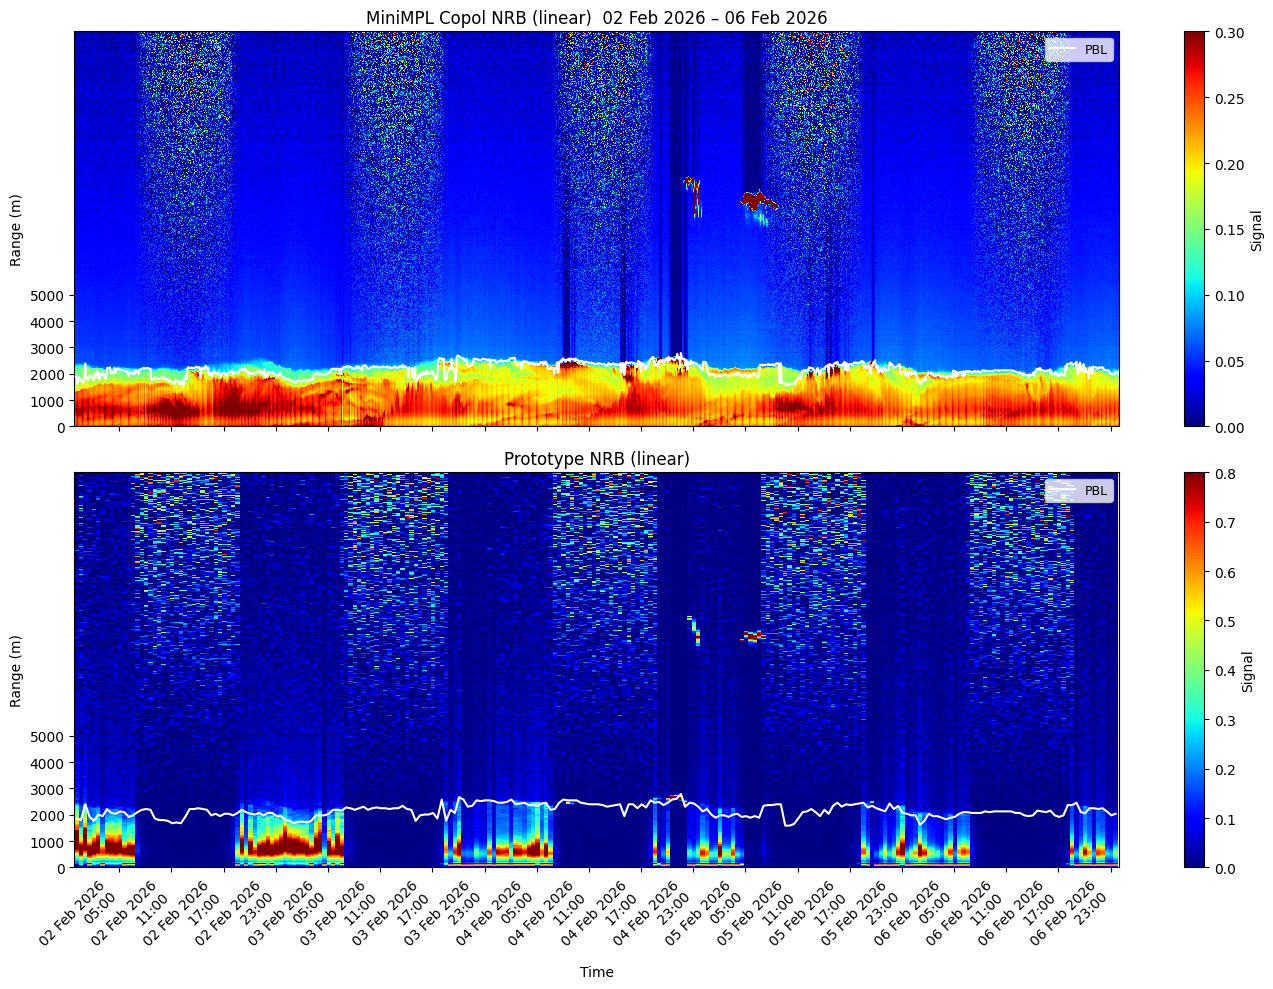

In [35]:
def plot_side_by_side(
    Z_top, Z_bot,
    title_top, title_bot,
    start_date, end_date,
    scale_top="linear", scale_bot="linear",
    ylim=(0, 11000),
    clim_top=(0, 0.3), clim_bot=(0, 0.3),
    cmap="jet",
    pbls=None,
    pbl_color="white",
    save=True,
    save_dir=SAVE_DIR,
    ytick_max=15000,
    ytick_step=3000,
):
    """Two curtain plots stacked vertically sharing the x axis."""

    def prep(Z, scale):
        if scale == "log":
            return np.log10(Z.clip(lower=1e-6)), f"log\u2081\u2080(Signal)"
        return Z.copy(), "Signal"

    Zt, lbl_t = prep(Z_top, scale_top)
    Zb, lbl_b = prep(Z_bot, scale_bot)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    pcm1 = ax1.pcolormesh(Zt.columns, Zt.index, Zt.values, shading="auto", cmap=cmap)
    pcm1.set_clim(*clim_top)
    fig.colorbar(pcm1, ax=ax1, label=lbl_t)

    pcm2 = ax2.pcolormesh(Zb.columns, Zb.index, Zb.values, shading="auto", cmap=cmap)
    pcm2.set_clim(*clim_bot)
    fig.colorbar(pcm2, ax=ax2, label=lbl_b)

    # ── PBL overlay on both panels ────────────────────────────────────────────
    if pbls is not None:
        pbls = pbls.copy()
        pbls.index = pd.to_datetime(pbls.index, errors="coerce")
        pbls = pbls.dropna()

        for ax, Z in [(ax1, Z_top), (ax2, Z_bot)]:
            Z_cols = pd.to_datetime(Z.columns, errors="coerce")
            pbl_line = pbls.reindex(Z_cols, method="nearest",
                                    tolerance=pd.Timedelta("5min"))
            pbl_line.index = Z_cols
            pbl_line = pd.to_numeric(pbl_line, errors="coerce")
            pbl_line = pbl_line.where(np.isfinite(pbl_line)).dropna()
            if len(pbl_line):
                ax.plot(pbl_line.index, pbl_line.values,
                        linewidth=1.5, color=pbl_color,
                        label="PBL", zorder=10)
                ax.legend(loc="upper right", fontsize=9)

    for ax in (ax1, ax2):
        if ylim:
            ax.set_ylim(ylim)
        ax.set_ylabel("Range (m)")
        ax.set_yticks(range(0, ytick_max + 1, ytick_step))
        ax.grid(False)

    ax1.set_title(f"{title_top} ({scale_top})  "
                  f"{pd.to_datetime(start_date):%d %b %Y} \u2013 "
                  f"{pd.to_datetime(end_date):%d %b %Y}")
    ax2.set_title(f"{title_bot} ({scale_bot})")

    ax2.xaxis.set_major_locator(mdates.HourLocator(interval=6))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y\n%H:%M"))
    plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")
    ax2.set_xlabel("Time")

    plt.tight_layout()

    if save:
        os.makedirs(save_dir, exist_ok=True)
        fname = (
            f"sidebyside_{pd.to_datetime(start_date):%Y%m%d}"
            f"_{pd.to_datetime(end_date):%Y%m%d}.png"
        )
        path = os.path.join(save_dir, fname)
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print(f"Saved \u2192 {path}")

    plt.show()


plot_side_by_side(
    Z_mpl_co_nrb, Z_proto,
    title_top="MiniMPL Copol NRB",
    title_bot="Prototype NRB",
    start_date=start_date,
    end_date=end_date,
    ylim=(0, 15000),
    clim_top=(0, 0.3),
    clim_bot=(0, 0.8),
    cmap="jet",
    pbls=pbl_series * 1000 if SHOW_PBL else None,
    pbl_color="white",
    ytick_max=5000,
    ytick_step=1000,
)


Saved → CombinedFigures/sidebyside_20260202_20260206.png


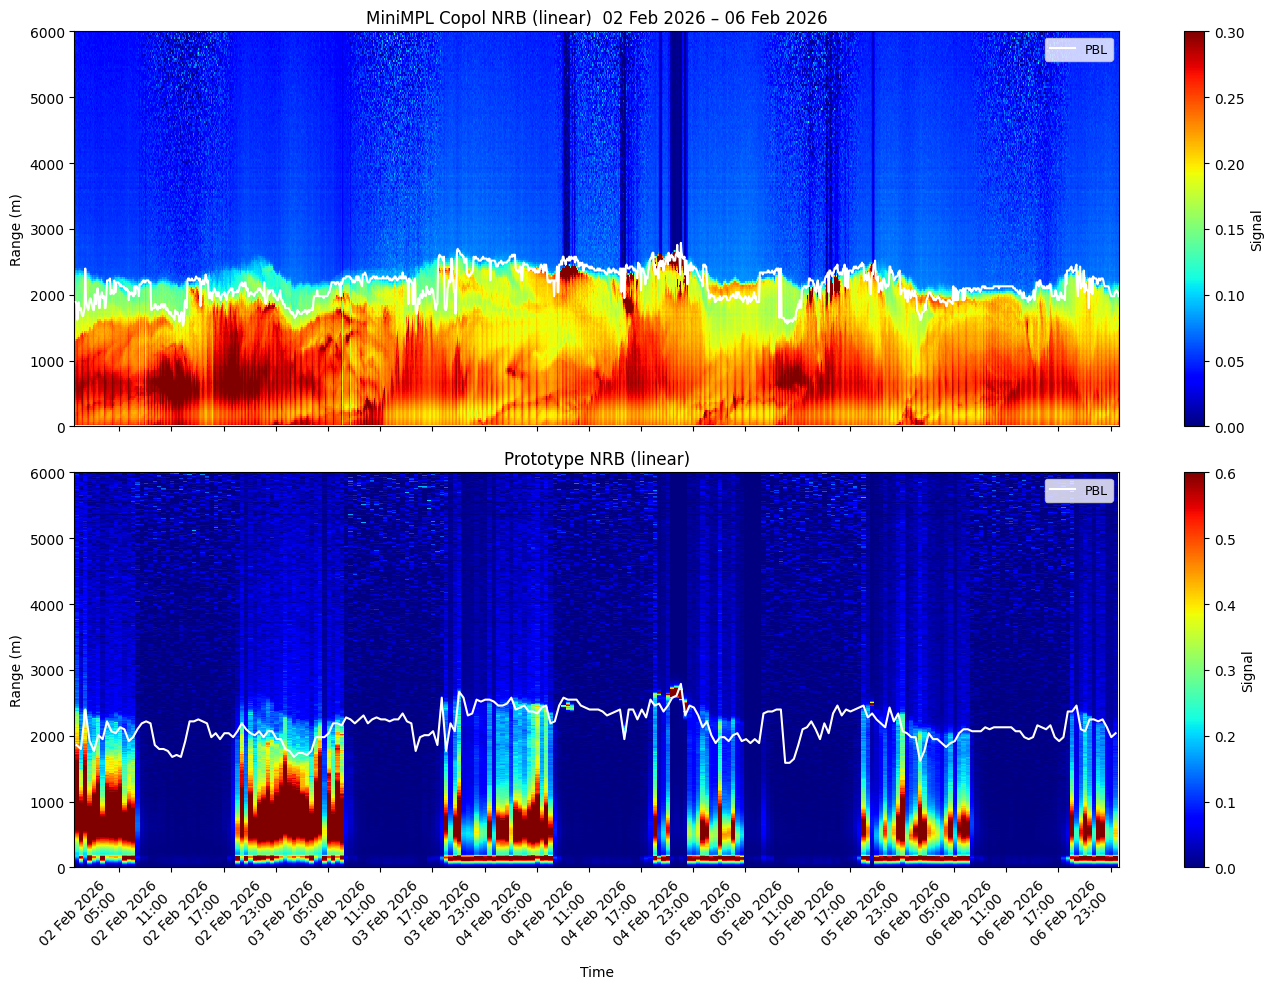

In [36]:
plot_side_by_side(
    Z_mpl_co_nrb, Z_proto,
    title_top="MiniMPL Copol NRB",
    title_bot="Prototype NRB",
    start_date=start_date,
    end_date=end_date,
    ylim=(0, 6000),
    clim_top=(0, 0.3),
    clim_bot=(0, 0.6),
    cmap="jet",
    pbls=pbl_series * 1000 if SHOW_PBL else None,
    pbl_color="white",
    ytick_max=6000,
    ytick_step=1000,
)

Saved → CombinedFigures/sidebyside_20260202_20260206.png


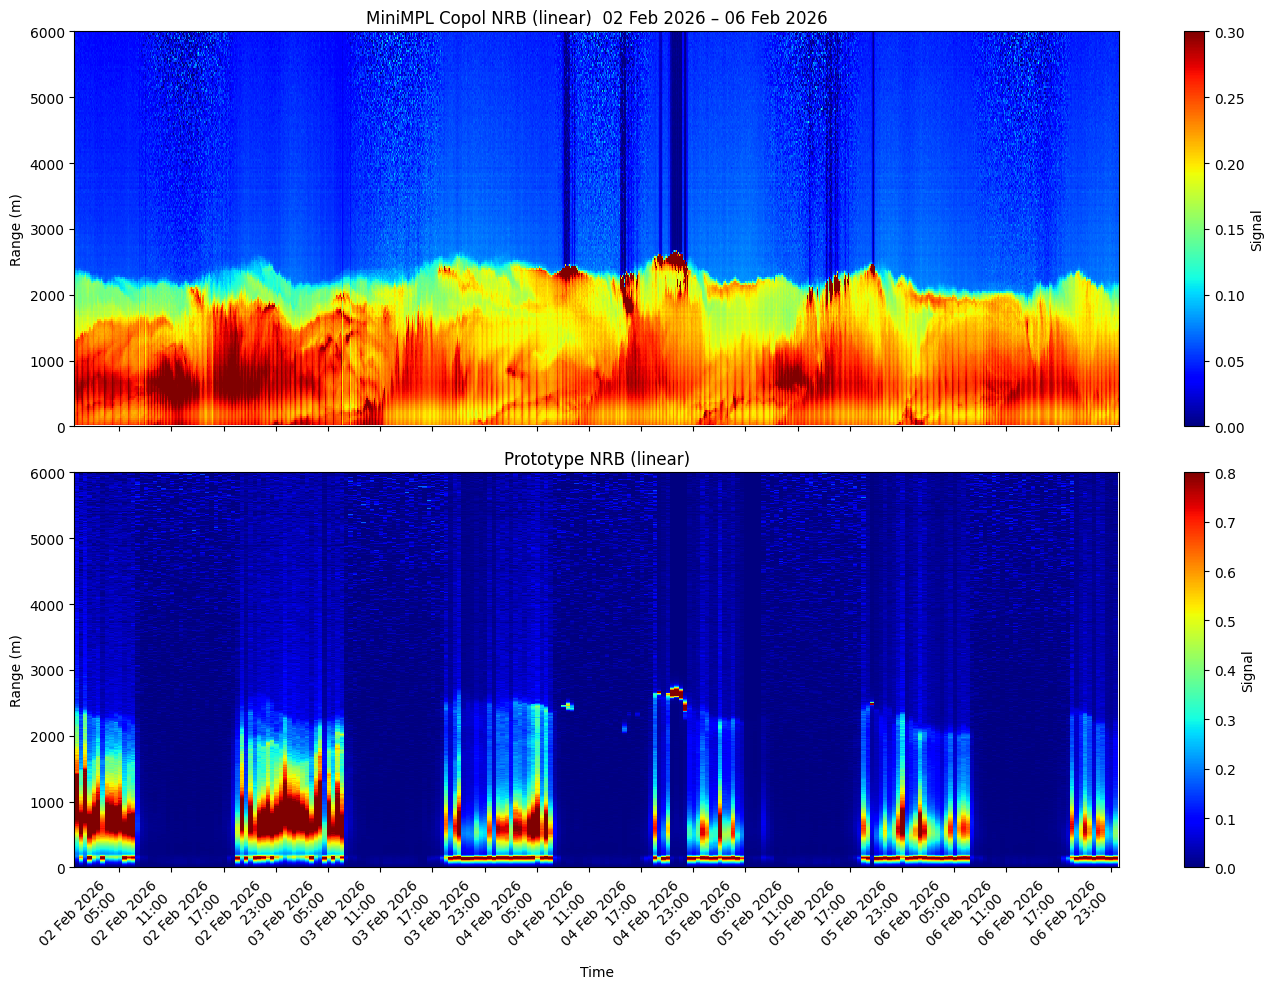

In [75]:
plot_side_by_side(
    Z_mpl_co_nrb, Z_proto,
    title_top="MiniMPL Copol NRB",
    title_bot="Prototype NRB",
    start_date=start_date,
    end_date=end_date,
    ylim=(0, 5000),
    clim_top=(0, 0.3),
    clim_bot=(0, 0.8),
    cmap="jet",
    pbls=None,
    pbl_color="white",
    ytick_max=6000,
    ytick_step=1000,
)

Saved → CombinedFigures/sidebyside_20260202_20260206.png


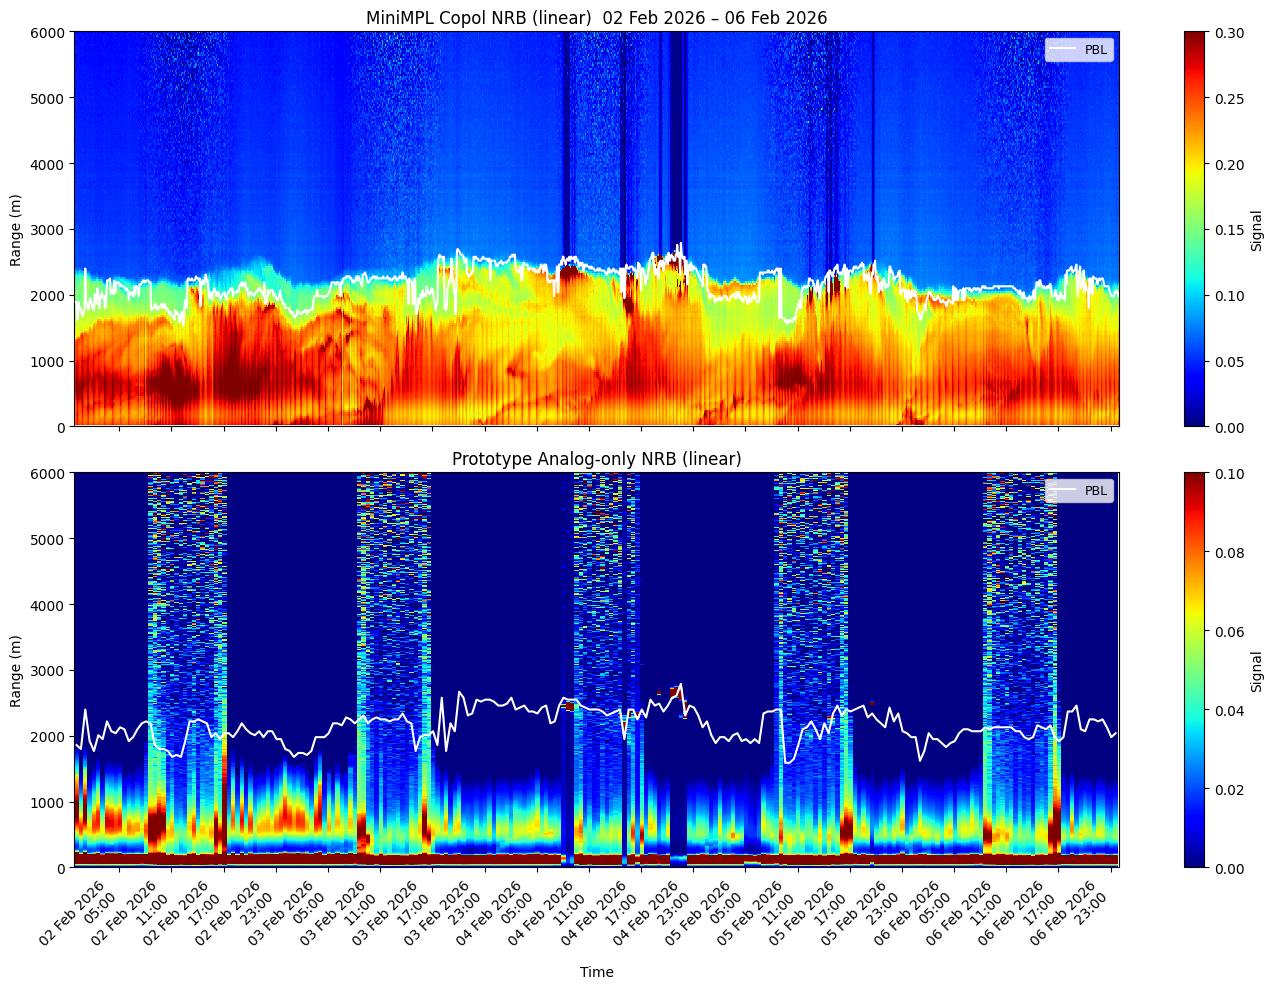

In [38]:
plot_side_by_side(
    Z_mpl_co_nrb, Z_analog_only,
    title_top="MiniMPL Copol NRB",
    title_bot="Prototype Analog-only NRB",
    start_date=start_date,
    end_date=end_date,
    ylim=(0, 6000),
    clim_top=(0, 0.3),
    clim_bot=(0, 0.1),
    cmap="jet",
    pbls=pbl_series * 1000 if SHOW_PBL else None,
    pbl_color="white",
    ytick_max=6000,
    ytick_step=1000,
)

Saved → CombinedFigures/sidebyside_20260202_20260206.png


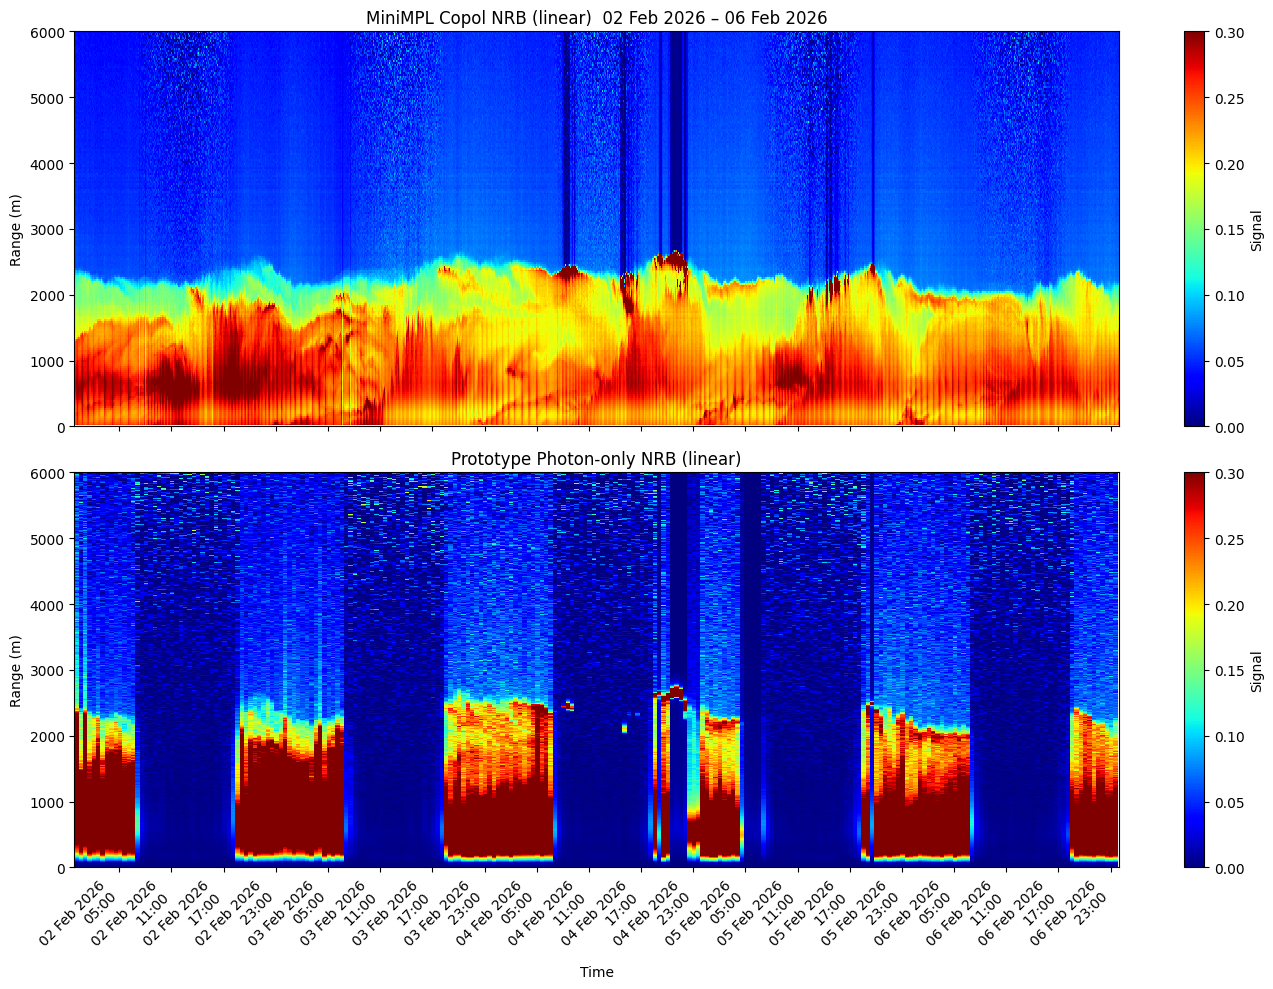

In [69]:
plot_side_by_side(
    Z_mpl_co_nrb, Z_photon_only,
    title_top="MiniMPL Copol NRB",
    title_bot="Prototype Photon-only NRB",
    start_date=start_date,
    end_date=end_date,
    ylim=(0, 6000),
    clim_top=(0, 0.3),
    clim_bot=(0, 0.3),
    cmap="jet",
    pbls=None,
    pbl_color="white",
    ytick_max=6000,
    ytick_step=1000,
)